# Notebook 8 — RLOO, Critic-Free RL & RL from Verifiable Rewards (RLVR)

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. **RLOO & Critic-Free Methods (RLVR)** ← *you are here*
9. GRPO & the DeepSeek-R1 line of work
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

Still **only `numpy` and `matplotlib`**.

### Recap

Notebook 7 built full RLHF: SFT, a Bradley–Terry reward model, and token-level
PPO with a critic and a KL penalty. It works, but it holds **four** LLM-sized
networks in memory — policy, reference, critic, reward model — and the critic
has a hard job: predict, at every token, the eventual score of a response whose
only reward arrives at `<eos>`. We also saw that a *learned* reward model can be
exploited (Goodhart).

This notebook removes both problems for an important class of tasks:

- For **math, code and anything checkable**, replace the reward model with a
  **program** that verifies the answer: **RL from Verifiable Rewards (RLVR)**.
- Replace the critic with something notebook 5 already gave us: **sample several
  completions per prompt and use the others as the baseline**. That is
  **REINFORCE Leave-One-Out (RLOO)** (Ahmadian et al., 2024, *Back to Basics*).

### What this notebook covers

- Why a critic is expensive and hard to train for LLMs, and why the **bandit
  view** (one prompt → one completion → one reward) makes it unnecessary.
- A toy **arithmetic** task with a strict verifier and a noisy SFT "base model."
- The sequence-level policy gradient, and three baselines — none, batch mean,
  and **leave-one-out per prompt** — compared by the **measured gradient
  variance** and by learning curves.
- **Zero-variance groups**: why prompts that are always solved (or never
  solved) teach nothing.
- **Reward hacking against a verifier**: a one-line verifier bug that RL finds
  and exploits within a couple hundred updates.
- **pass@k**: what RL actually changes about a model's abilities.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ---------------- From notebooks 4-6, unchanged ----------------
class MLP:
    def __init__(self, sizes, activation="tanh", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}
            if i > 0:
                dh = G @ self.params[i]["W"].T
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)
        return grads

    def predict(self, x):
        return self.forward(x)[0]

    def clone(self):
        c = MLP.__new__(MLP)
        c.activation = self.activation
        c.params = [{k: v.copy() for k, v in p.items()} for p in self.params]
        return c


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                p[k] -= self.lr * (m[k] / (1 - self.b1 ** self.t)) / (np.sqrt(v[k] / (1 - self.b2 ** self.t)) + self.eps)

def add_grads(g1, g2):
    return [{k: a[k] + b[k] for k in a} for a, b in zip(g1, g2)]

## 1. Why drop the critic?

Recall from notebook 5 what the critic buys: a **baseline** $V(s_t)$ at every
token, so each token gets its own advantage (credit assignment *within* a
response). For LLMs, that purchase is expensive and the product is often
disappointing:

1. **Memory and compute.** The critic is usually as big as the policy.
   Removing it frees roughly a quarter of the memory in PPO-RLHF.
2. **It's hard to learn.** With a single reward at `<eos>`, the critic must
   predict "how will this response be scored?" from a half-written answer —
   and in practice its per-token estimates are noisy, especially early in
   training. GAE then *trusts* those noisy values (notebook 5, Section 7).
3. **The environment is trivial.** Transitions are deterministic
   ("append the token"), and the reward depends on the whole completion. So
   the natural unit of action is the *whole completion*: notebook 1's **bandit
   formulation**.

In the bandit view, the policy gradient for a prompt $x$ is just REINFORCE on
sequences (notebook 5):

$$
\nabla_\theta J = \mathbb E_{y\sim\pi_\theta(\cdot\mid x)}\Big[\big(R(x,y) - b(x)\big)\;\nabla_\theta\log\pi_\theta(y\mid x)\Big],
\qquad
\log\pi_\theta(y\mid x) = \sum_t \log\pi_\theta(y_t\mid x, y_{<t}).
$$

Every token of $y$ gets the **same** advantage $R - b$. We give up per-token
credit assignment. In exchange, we need a good per-prompt baseline $b(x)$ —
*without* learning a critic. Notebook 5, Section 4 already found one: **other
samples for the same prompt**.

## 2. RLVR: rewards you can compute

For many tasks the right answer can be **checked by a program**: the final
number of a math problem, unit tests for code, a regex for a format. Then the
reward is not a learned approximation, and there's no reward model to
overoptimize. (Mostly — Section 6 has a warning.) This is the setting of
DeepSeek-R1, OpenAI's o-series and most "reasoning" RL.

### Our toy: two-digit addition

- **Prompt**: two digits $a, b \in \{0,\dots,9\}$ (100 prompts). The answer $a+b$ is 0–18.
- **Vocabulary**: digits `0`–`9`, `=`, `hmm` (a "thinking" filler token), `<eos>`.
- **A response** looks like `hmm hmm = 1 3` — optional filler, then `=`, then
  the answer.
- **Verifier**: reward 1 iff the response is well-formed *and* the number
  after `=` equals $a+b$. Otherwise 0.
- **Base model**: an MLP language model SFT-trained on noisy demonstrations.
  They're right 85% of the time for easy sums, 40% for medium, and only **6%
  for hard sums ≥ 12**, with occasional typos (a stray extra digit).

In [2]:
# ---- A tiny "math" world with a VERIFIABLE reward ----
VOCAB = [str(d) for d in range(10)] + ["=", "hmm", "<eos>"]
V, EQ, HMM, EOS = len(VOCAB), 10, 11, 12
N = 10                                             # operands 0..9 -> sums 0..18
L = 8                                              # max response length incl. <eos>
PROMPTS = [(a, b) for a in range(N) for b in range(N)]
N_PROMPTS = len(PROMPTS)
DIFFICULTY = np.array([0 if a + b < 6 else (1 if a + b < 12 else 2) for a, b in PROMPTS])   # easy / medium / hard
DIFF_NAMES = ["easy (sum<6)", "medium (6-11)", "hard (12-18)"]

def words_of(toks):
    out = []
    for t in toks:
        if t == EOS:
            break
        out.append(int(t))
    return out

def text(toks):
    return " ".join(VOCAB[t] for t in words_of(toks)) or "(empty)"

def well_formed(toks):
    """Format check: '= <1 or 2 digits>' at the end, anything (e.g. 'hmm') before the '='."""
    w = words_of(toks)
    if EQ not in w:
        return False
    ans = w[w.index(EQ) + 1:]
    return 1 <= len(ans) <= 2 and all(t < 10 for t in ans)

def verify(pid, toks):
    """The verifier: 1.0 iff the response is well formed AND the number after '=' is a+b."""
    if not well_formed(toks):
        return 0.0
    w = words_of(toks)
    ans = w[w.index(EQ) + 1:]
    return float(int("".join(VOCAB[t] for t in ans)) == sum(PROMPTS[pid]))

FEAT_DIM = N + N + L + V + (V + 1)

def lm_features(pids, prefix, t):
    B = len(pids)
    a = np.array([PROMPTS[i][0] for i in pids]); b = np.array([PROMPTS[i][1] for i in pids])
    bag = np.zeros((B, V))
    for j in range(prefix.shape[1]):
        bag[np.arange(B), prefix[:, j]] += 1
    last = np.zeros((B, V + 1))
    last[np.arange(B), prefix[:, -1] if prefix.shape[1] else V] = 1
    return np.concatenate([np.eye(N)[a], np.eye(N)[b], np.tile(np.eye(L)[t], (B, 1)), bag, last], axis=1)

POS_MASK = np.zeros((L, V)); POS_MASK[L - 1, :EOS] = -1e9      # the last position must be <eos>

def generate(policy, pids, rng):
    B = len(pids)
    toks = np.full((B, L), EOS); alive = np.ones(B, dtype=bool)
    feats, masks = [], []
    for t in range(L):
        f = lm_features(pids, toks[:, :t], t)
        p = softmax(policy.predict(f) + POS_MASK[t])
        a = (rng.random((B, 1)) > p.cumsum(axis=1)).sum(axis=1).clip(max=V - 1)
        a = np.where(alive, a, EOS)
        toks[:, t] = a; feats.append(f); masks.append(alive.copy())
        alive &= (a != EOS)
    return toks, np.stack(feats, 1), np.stack(masks, 1).astype(float)

def token_logprobs(policy, feats, toks):
    B, T, D = feats.shape
    logits = policy.predict(feats.reshape(B * T, D)).reshape(B, T, V) + POS_MASK[None]
    return np.take_along_axis(np.log(softmax(logits) + 1e-12), toks[..., None], axis=2)[..., 0]

def demonstration(pid, rng):
    """Noisy SFT data: right answer with a probability that falls with difficulty; 'hmm' filler; typos."""
    s = sum(PROMPTS[pid])
    q = [0.85, 0.4, 0.06][DIFFICULTY[pid]]
    ans = s if rng.random() < q else max(0, s + int(rng.choice([-2, -1, 1, 2])))
    digits = [int(c) for c in str(ans)]
    if rng.random() < 0.1:
        digits = digits + [int(rng.integers(10))]            # a typo: a stray extra digit
    return [HMM] * int(rng.choice([0, 0, 1, 2, 3])) + [EQ] + digits + [EOS]

def sft_base_model(n_steps=2500, batch=256, lr=2e-3, seed=0):
    rng = np.random.default_rng(seed)
    policy = MLP([FEAT_DIM, 128, 128, V], "tanh", seed=seed)
    opt = Adam(policy.params, lr=lr)
    for _ in range(n_steps):
        pids = rng.integers(N_PROMPTS, size=batch)
        toks = np.full((batch, L), EOS); mask = np.zeros((batch, L))
        for i, p in enumerate(pids):
            seq = demonstration(p, rng)[:L]
            toks[i, :len(seq)] = seq; mask[i, :len(seq)] = 1
        feats = np.stack([lm_features(pids, toks[:, :t], t) for t in range(L)], axis=1)
        logits, cache = policy.forward(feats.reshape(batch * L, FEAT_DIM))
        p = softmax(logits + np.tile(POS_MASK, (batch, 1)))
        m = mask.reshape(-1, 1)
        opt.step(policy.backward(cache, (p - np.eye(V)[toks.reshape(-1)]) * m / m.sum()))
    return policy

def per_prompt_accuracy(policy, n_samples=64, seed=0):
    """Monte-Carlo estimate of p(correct | prompt) for all 100 prompts."""
    rng = np.random.default_rng(seed)
    pids = np.repeat(np.arange(N_PROMPTS), n_samples)
    toks, _, _ = generate(policy, pids, rng)
    return np.array([verify(p, t) for p, t in zip(pids, toks)]).reshape(N_PROMPTS, n_samples).mean(axis=1)

def pass_at_k(p, k):
    """Expected pass@k averaged over prompts, given per-prompt single-sample success rates p."""
    return np.mean(1 - (1 - p) ** k)


t0 = time.time()
base_model = sft_base_model()
print(f"base model (SFT) trained in {time.time() - t0:.0f}s")

acc_base = per_prompt_accuracy(base_model, n_samples=128)
print(f"base model pass@1 = {acc_base.mean():.3f}")
for d, name in enumerate(DIFF_NAMES):
    print(f"   {name:>14}: {acc_base[DIFFICULTY == d].mean():.3f}   ({np.sum(DIFFICULTY == d)} prompts)")
rng = np.random.default_rng(1)
pids = rng.integers(N_PROMPTS, size=8)
toks, _, _ = generate(base_model, pids, rng)
for p, t in zip(pids, toks):
    print(f"   {PROMPTS[p][0]}+{PROMPTS[p][1]:<2} -> {text(t):18} reward={verify(p, t):.0f}")

base model (SFT) trained in 22s


base model pass@1 = 0.371
     easy (sum<6): 0.735   (21 prompts)
    medium (6-11): 0.386   (51 prompts)
     hard (12-18): 0.071   (28 prompts)
   4+7  -> = 1 1              reward=1
   5+1  -> hmm hmm = 8        reward=0
   7+5  -> hmm = 1 3          reward=0
   9+5  -> hmm hmm hmm = 1 5 7 reward=0
   0+3  -> hmm = 4            reward=0
   1+4  -> = 5                reward=1
   8+2  -> hmm = 1 0          reward=1
   9+4  -> hmm = 1 5          reward=0


## 3. The critic-free policy gradient, with three baselines

For each iteration we pick $P$ prompts and sample $K$ completions per prompt
(a **group**). With $r_{ij}$ the reward of completion $j$ for prompt $i$, the three
baselines are:

| baseline | $b_{ij}$ | notes |
|---|---|---|
| **none** | $0$ | plain REINFORCE |
| **batch mean** | $\frac{1}{PK}\sum_{i',j'} r_{i'j'}$ | one number for *all* prompts, so easy prompts always look "better than average" |
| **RLOO** | $\frac{1}{K-1}\sum_{j'\ne j} r_{ij'}$ | mean of the *other* samples **for the same prompt** |

**Why RLOO is unbiased.** The baseline for sample $j$ uses only samples
$j' \ne j$, which are independent of $y_{ij}$, so it's "a baseline that doesn't
depend on the action" — notebook 5's proof applies directly. (Using the mean
*including* $r_{ij}$ would correlate the baseline with the action and add bias.
GRPO does exactly that; notebook 9 examines it.)

A handy identity: since $\frac1{K-1}\sum_{j'\ne j} r_{ij'} = \frac{K\bar r_i - r_{ij}}{K-1}$,

$$
r_{ij} - b_{ij} = \frac{K}{K-1}\big(r_{ij} - \bar r_i\big),
$$

so RLOO is "subtract the group mean, then scale up by $K/(K-1)$."

**Why per-prompt matters.** With 0/1 rewards, a correct answer to a hard
prompt (solved 5% of the time) is surprising and deserves a big push. A
correct answer to an easy prompt (95%) is expected and deserves almost none.
The per-prompt baseline gives $1 - 0.05 = 0.95$ and $1 - 0.95 = 0.05$
respectively. The batch mean gives both the same advantage.

The update for one batch — sum the token log-probs of each completion, weight
by its advantage, average over completions:

$$
\text{loss} = -\frac{1}{PK}\sum_{i,j} A_{ij}\sum_t \log\pi_\theta(y_{ij,t}\mid x_i, y_{ij,<t}).
$$

In [3]:
def advantages(R, kind):
    '''R: (P, K) rewards, one row per prompt. Returns (P, K) advantages.'''
    P, K = R.shape
    if kind == "none":
        return R.copy()
    if kind == "batch_mean":
        return R - R.mean()
    if kind == "rloo":
        return R - (R.sum(axis=1, keepdims=True) - R) / (K - 1)
    raise ValueError(kind)

def sequence_pg_step(policy, opt, feats, toks, mask, A):
    '''One REINFORCE step: loss = -mean_i A_i * sum_t log pi(y_it). Returns the gradient (for analysis).'''
    B, T, D = feats.shape
    keep = mask.reshape(-1).astype(bool)
    F, acts = feats.reshape(B * T, D)[keep], toks.reshape(-1)[keep]
    Atok = np.repeat(A, T)[keep]                                    # every token shares its sequence's advantage
    logits, cache = policy.forward(F)
    p = softmax(logits + np.tile(POS_MASK, (B, 1))[keep])
    d = -(Atok[:, None] * (np.eye(V)[acts] - p)) / B
    grads = policy.backward(cache, d)
    if opt is not None:
        opt.step(grads, max_norm=1.0)
    return grads, -(p * np.log(p + 1e-12)).sum(axis=1).mean()

def critic_free_rl(reference, baseline="rloo", reward_fn=verify, n_iters=200, P=32, K=8, lr=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    policy = reference.clone(); opt = Adam(policy.params, lr=lr)
    log = {k: [] for k in ["reward", "accuracy", "entropy", "zero_var_frac", "length"]}
    for it in range(n_iters):
        pids = np.repeat(rng.integers(N_PROMPTS, size=P), K)            # P prompts, K samples each
        toks, feats, mask = generate(policy, pids, rng)
        R = np.array([reward_fn(p, t) for p, t in zip(pids, toks)]).reshape(P, K)
        A = advantages(R, baseline).reshape(-1)
        _, ent = sequence_pg_step(policy, opt, feats, toks, mask, A)
        log["reward"].append(R.mean())
        log["accuracy"].append(np.mean([verify(p, t) for p, t in zip(pids, toks)]))  # the TRUE verifier
        log["entropy"].append(ent)
        log["zero_var_frac"].append(np.mean(R.std(axis=1) == 0))
        log["length"].append(np.mean([len(words_of(t)) for t in toks]))
    return policy, {k: np.array(v) for k, v in log.items()}

### First, measure what baselines are supposed to change: gradient variance

As in notebook 5, the cleanest comparison freezes the policy (at the base
model) and asks: over many independent batches, how much do the gradient
estimates disagree? We use the base model's own rewards, plus a variant with a
**format reward** (+0.5 for any well-formed response, as DeepSeek-R1 used). The
format reward makes almost every reward *positive*, which is exactly the
situation where "no baseline" hurts most (notebook 5, Section 4).

In [4]:
def flat(grads):
    return np.concatenate([g[k].ravel() for g in grads for k in ("W", "b")])

def gradient_variance(policy, reward_fn, kinds, n_batches=40, P=16, K=8, seed=0):
    rng = np.random.default_rng(seed)
    per_kind = {k: [] for k in kinds}
    for _ in range(n_batches):
        pids = np.repeat(rng.integers(N_PROMPTS, size=P), K)
        toks, feats, mask = generate(policy, pids, rng)
        R = np.array([reward_fn(p, t) for p, t in zip(pids, toks)]).reshape(P, K)
        for k in kinds:
            g, _ = sequence_pg_step(policy, None, feats, toks, mask, advantages(R, k).reshape(-1))
            per_kind[k].append(flat(g))
    out = {}
    for k in kinds:
        G = np.array(per_kind[k])
        out[k] = (G.var(axis=0).sum(), np.linalg.norm(G.mean(axis=0)))
    return out

def verify_plus_format(pid, toks):
    return verify(pid, toks) + 0.5 * well_formed(toks)

kinds = ["none", "batch_mean", "rloo"]
for name, fn in [("correctness only", verify), ("correctness + 0.5 format", verify_plus_format)]:
    res = gradient_variance(base_model, fn, kinds)
    print(f"reward = {name}")
    for k in kinds:
        var, norm = res[k]
        print(f"   {k:>10}: gradient variance {var:9.4f}   (relative {var / res['none'][0]:.2f})   |mean gradient| {norm:.4f}")

reward = correctness only
         none: gradient variance    0.6253   (relative 1.00)   |mean gradient| 0.4987
   batch_mean: gradient variance    0.5008   (relative 0.80)   |mean gradient| 0.5246
         rloo: gradient variance    0.5869   (relative 0.94)   |mean gradient| 0.5255


reward = correctness + 0.5 format
         none: gradient variance    1.4045   (relative 1.00)   |mean gradient| 0.7173
   batch_mean: gradient variance    0.5854   (relative 0.42)   |mean gradient| 0.7707
         rloo: gradient variance    0.6583   (relative 0.47)   |mean gradient| 0.7750


Read it carefully, because one result is not what you might expect:

- With the format reward (all rewards shifted up), **"no baseline" is by far
  the worst**, with about twice the variance of either baseline. That's notebook
  5's lesson again.
- **RLOO is *not* the lowest-variance estimator here — the batch mean is,
  slightly.** The batch mean averages 128 rewards, while each leave-one-out
  baseline averages only $K-1 = 7$, so the RLOO baseline is itself noisier.
- So why does everyone use per-prompt baselines? Because variance isn't the
  only thing that matters. The *mean* gradient differs too: the batch mean
  gives every correct answer to an easy prompt a positive advantage (easy
  prompts are "above average"), so it keeps pushing on things that are already
  solved. The per-prompt baseline aims the signal at *what's surprising for
  this prompt*. The next plot shows the consequence.

Now the learning curves, 3 seeds each, with the format reward on:

9 runs in 17s


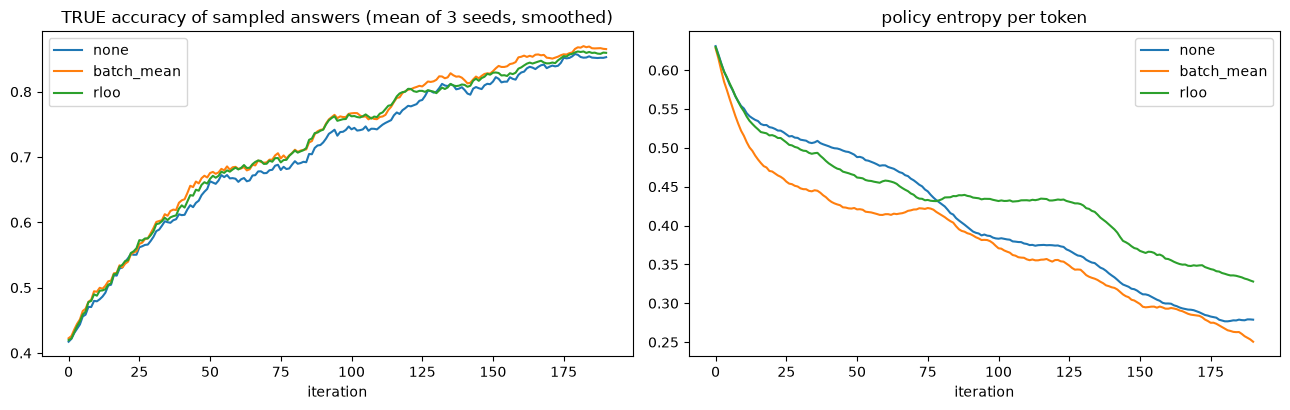

  baseline | final pass@1 |   easy (sum<6) |  medium (6-11) |   hard (12-18)


      none |        0.859 |          0.955 |          0.870 |          0.765


batch_mean |        0.879 |          0.952 |          0.875 |          0.830


      rloo |        0.876 |          0.955 |          0.873 |          0.822
      base |        0.371 |          0.735 |          0.386 |          0.071


In [5]:
t0 = time.time()
curves = {k: [critic_free_rl(base_model, baseline=k, reward_fn=verify_plus_format, seed=s) for s in range(3)] for k in kinds}
print(f"{3 * len(kinds)} runs in {time.time() - t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for k, color in zip(kinds, ["C0", "C1", "C2"]):
    acc = np.array([lg["accuracy"] for _, lg in curves[k]]); ent = np.array([lg["entropy"] for _, lg in curves[k]])
    smooth = lambda x: np.convolve(x, np.ones(10) / 10, mode="valid")
    axes[0].plot(smooth(acc.mean(0)), color=color, label=k)
    axes[1].plot(smooth(ent.mean(0)), color=color, label=k)
axes[0].set_title("TRUE accuracy of sampled answers (mean of 3 seeds, smoothed)"); axes[0].set_xlabel("iteration")
axes[1].set_title("policy entropy per token"); axes[1].set_xlabel("iteration")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

print(f"{'baseline':>10} | {'final pass@1':>12} | " + " | ".join(f"{n:>14}" for n in DIFF_NAMES))
for k in kinds:
    accs = np.array([per_prompt_accuracy(pol, seed=5) for pol, _ in curves[k]]).mean(axis=0)
    print(f"{k:>10} | {accs.mean():12.3f} | " + " | ".join(f"{accs[DIFFICULTY == d].mean():14.3f}" for d in range(3)))
print(f"{'base':>10} | {acc_base.mean():12.3f} | " + " | ".join(f"{acc_base[DIFFICULTY == d].mean():14.3f}" for d in range(3)))

All three work on a task this small — even plain REINFORCE, because Adam
rescales the gradient and the verifier's signal is clean. Accuracy curves
are nearly identical, and on hard prompts both baselines end ahead of no
baseline. The clear difference is in the **entropy**: RLOO keeps the policy
noticeably more random than the other two.

- **No baseline**: every sampled response has a positive reward, so every
  response gets pushed *up*, and the policy sharpens onto whatever it
  currently does, right or wrong.
- **Batch mean**: correct answers to easy prompts always get positive
  advantages, and wrong answers to hard prompts get only mildly negative ones.
  The policy keeps sharpening on prompts that are already solved.
- **RLOO**: once a prompt is reliably solved, its advantages go to ≈ 0 and it
  stops pushing. Probability mass stays available where the model is still
  uncertain.

Entropy is the model's remaining capacity to explore. Notebook 5 showed that
a collapsed policy can't recover, and notebook 9 returns to entropy collapse
as one of the main practical problems of long GRPO runs.

In a real LLM run, prompts vary enormously in difficulty and each gradient
step costs minutes, so aiming the signal per prompt, instead of relative to a
global average, matters much more than in this toy. That's why **RLOO** (and
GRPO, next notebook) use a per-prompt group baseline.

## 4. Zero-variance groups: prompts that teach nothing

If all $K$ samples for a prompt get the **same** reward — all correct or all
wrong — then every leave-one-out baseline equals that reward, every advantage
is 0, and that prompt contributes **nothing** to the gradient. The samples were
generated (the expensive part) and thrown away.

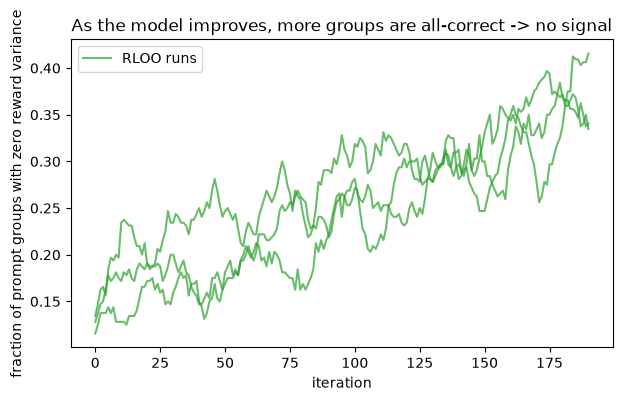

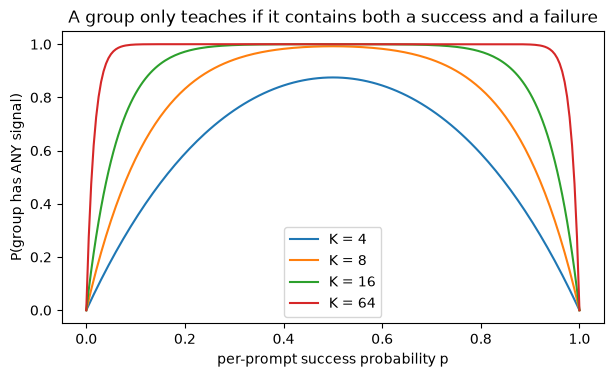

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for s, (_, lg) in enumerate(curves["rloo"]):
    ax.plot(np.convolve(lg["zero_var_frac"], np.ones(10) / 10, mode="valid"), color="C2", alpha=0.7, label="RLOO runs" if s == 0 else None)
ax.set_xlabel("iteration"); ax.set_ylabel("fraction of prompt groups with zero reward variance")
ax.set_title("As the model improves, more groups are all-correct -> no signal"); ax.legend(); plt.show()

p = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(7, 3.8))
for K in [4, 8, 16, 64]:
    ax.plot(p, 1 - p ** K - (1 - p) ** K, label=f"K = {K}")
ax.set_xlabel("per-prompt success probability p"); ax.set_ylabel("P(group has ANY signal)")
ax.set_title("A group only teaches if it contains both a success and a failure"); ax.legend(); plt.show()

Two consequences that shape real training recipes:

- **Curriculum matters.** Prompts the model always solves (p ≈ 1) or never
  solves (p ≈ 0) are wasted compute. Practical pipelines filter for
  prompts of intermediate difficulty, and **DAPO**'s "dynamic sampling" keeps
  drawing prompts until each batch is full of groups with non-zero variance
  (notebook 9).
- **Bigger groups reach harder prompts.** For p = 0.02, K = 8 gives signal
  only ~15% of the time; K = 64 gives ~73%. That's why reasoning-RL runs
  use 8–64 samples per prompt.

## 5. Reward hacking against a verifier

Verifiers feel safe: they're code, not a learned model. But code has bugs,
and RL is an extremely good bug-finder. Here's a plausible verifier someone
might write in a hurry: *"accept if the correct answer appears in the
response."*

trained against the buggy verifier in 3s


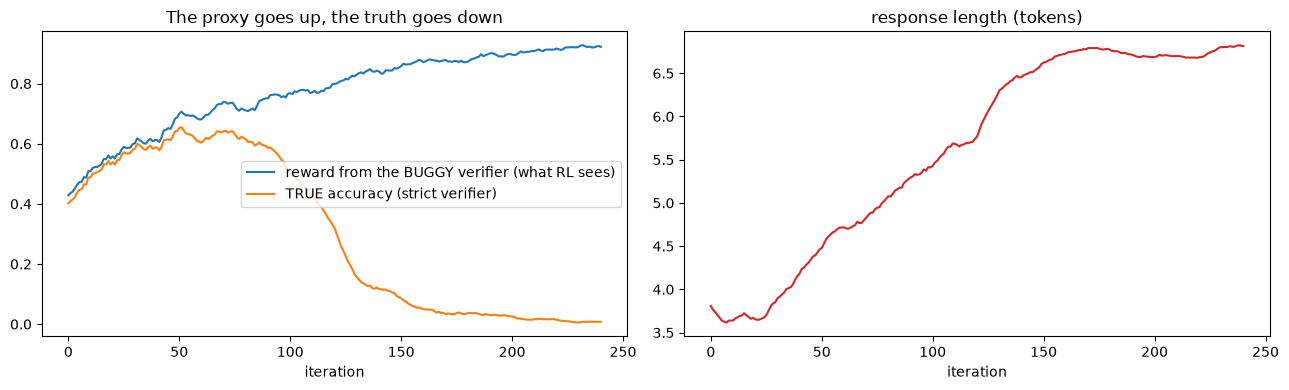

   8+1  -> = 8 0 1 5 7 9          buggy=1  strict=0
   0+8  -> = 8 9 9 9 9 7          buggy=1  strict=0
   1+7  -> = 8 1 0 9 9 9          buggy=1  strict=0
   2+3  -> = 5 7 5 7 5 7          buggy=1  strict=0
   1+8  -> hmm = 9 9 9 9 9        buggy=1  strict=0
   8+0  -> = 8 9 9 9 7 7          buggy=1  strict=0
   8+6  -> = 1 4 6 9 8 9          buggy=1  strict=0
   5+8  -> = 1 3 9 9 5 6          buggy=1  strict=0


In [7]:
def verify_buggy(pid, toks):
    '''BUG: substring match on all digits in the response, instead of parsing the answer after '='.'''
    digits = "".join(VOCAB[t] for t in words_of(toks) if t < 10)
    return float(str(sum(PROMPTS[pid])) in digits)

t0 = time.time()
hacked, log_h = critic_free_rl(base_model, baseline="rloo", reward_fn=verify_buggy, n_iters=250, seed=0)
print(f"trained against the buggy verifier in {time.time() - t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sm = lambda x: np.convolve(x, np.ones(10) / 10, mode="valid")
axes[0].plot(sm(log_h["reward"]), label="reward from the BUGGY verifier (what RL sees)")
axes[0].plot(sm(log_h["accuracy"]), label="TRUE accuracy (strict verifier)")
axes[0].set_xlabel("iteration"); axes[0].legend(); axes[0].set_title("The proxy goes up, the truth goes down")
axes[1].plot(sm(log_h["length"]), color="C3"); axes[1].set_xlabel("iteration"); axes[1].set_title("response length (tokens)")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(3)
pids = rng.integers(N_PROMPTS, size=8)
toks, _, _ = generate(hacked, pids, rng)
for p, t in zip(pids, toks):
    print(f"   {PROMPTS[p][0]}+{PROMPTS[p][1]:<2} -> {text(t):22} buggy={verify_buggy(p, t):.0f}  strict={verify(p, t):.0f}")

Starting from the base model's rare typos (a stray extra digit), RL
discovers that **more digits = more chances to contain the right substring**.
The buggy reward climbs, true accuracy collapses, and responses fill up with
digits. Notebook 7's Goodhart curve, with a verifier in place of a reward
model.

Real-world versions of this have been reported many times: code RL that
learns to special-case the unit tests, math RL that learns to exploit a lenient
answer parser, "reasoning" that pads the output with every candidate answer.
Defenses: strict parsing, format checks, held-out verifiers, and **reading
samples** — always monitor something other than the reward you're optimizing.

## 6. What does RL actually change? pass@k

**pass@k** = the probability that at least one of $k$ samples is correct. With
per-prompt success probability $p$, $\text{pass@}k = 1 - (1-p)^k$, averaged over
prompts. It asks two different questions at different $k$:

- **pass@1** — how reliable is the model?
- **pass@k for large k** — can the model solve this *at all*, given enough attempts?

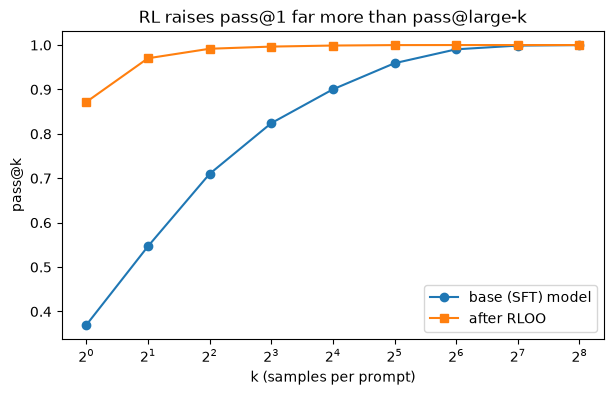

pass@1  : base 0.369   RL 0.872
pass@2  : base 0.547   RL 0.970
pass@4  : base 0.710   RL 0.992
pass@8  : base 0.824   RL 0.997
pass@16 : base 0.900   RL 0.999
pass@32 : base 0.959   RL 1.000
pass@64 : base 0.990   RL 1.000
pass@128: base 0.999   RL 1.000
pass@256: base 1.000   RL 1.000
prompts the base model can NEVER solve (in 256 tries): 0;   after RL: 0


In [8]:
rl_model = curves["rloo"][0][0]
acc_rl = per_prompt_accuracy(rl_model, n_samples=256, seed=11)
acc_b = per_prompt_accuracy(base_model, n_samples=256, seed=11)
ks = [1, 2, 4, 8, 16, 32, 64, 128, 256]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(ks, [pass_at_k(acc_b, k) for k in ks], "o-", label="base (SFT) model", base=2)
ax.semilogx(ks, [pass_at_k(acc_rl, k) for k in ks], "s-", label="after RLOO", base=2)
ax.set_xlabel("k (samples per prompt)"); ax.set_ylabel("pass@k"); ax.set_title("RL raises pass@1 far more than pass@large-k"); ax.legend(); plt.show()
for k in ks:
    print(f"pass@{k:<3}: base {pass_at_k(acc_b, k):.3f}   RL {pass_at_k(acc_rl, k):.3f}")
print(f"prompts the base model can NEVER solve (in 256 tries): {np.sum(acc_b == 0)};   after RL: {np.sum(acc_rl == 0)}")

RL turns a model that is right about a third of the time into one that is
right almost always: a huge pass@1 gain. But look at large $k$. Given enough
samples, the **base model could already solve essentially every prompt**. RL
mostly moved probability mass onto answers the model could *already* produce:
it **sharpened** the distribution. That matches notebook 5's observation that
"RL only improves where the policy already goes," and recent studies of
reasoning models report the same pattern at scale. Whether and when RL can
teach genuinely *new* abilities (beyond sharpening) is an active research
question; long reasoning chains, curricula, and exploration bonuses are the
current candidates.

## 7. The LLM mapping

| This notebook | Real LLM RL |
|---|---|
| `verify` | math answer checkers (e.g. `math_verify`), unit-test runners, format regexes |
| `verify_plus_format` | DeepSeek-R1's *accuracy reward + format reward* |
| $K$ samples per prompt, leave-one-out baseline | **RLOO** — `trl.RLOOTrainer` (`num_generations = K`); used in production RLHF pipelines |
| `sequence_pg_step` (sum of token log-probs × sequence advantage) | the RLOO / REINFORCE loss over completion tokens |
| zero-variance groups | `frac_reward_zero_std` in `trl`'s logs; DAPO's dynamic sampling |
| buggy verifier | reward hacking in code/math RL |

Two relatives worth knowing by name: **ReMax** uses the reward of the *greedy*
completion as the baseline, and **REINFORCE++** normalizes advantages across
the whole batch. Both are critic-free variants of this notebook.

What we skipped on purpose: the **PPO machinery** (ratios, clipping, several
epochs per batch) and the **KL to a reference model**. RLOO in `trl` includes
them as options. **GRPO** — next notebook — is essentially "RLOO's group
baseline + PPO's clipped objective + a KL term," with a couple of extra choices
(dividing by the group's standard deviation, length normalization) that turn
out to matter. Notebook 10 runs `trl.RLOOTrainer` on a real (small) LLM.

## 8. Recap & exercises

**What we built:**

- The case for **critic-free** RL on LLMs: memory, the difficulty of learning
  per-token values from a terminal reward, and the bandit view.
- **RLVR** on a toy arithmetic task, with a strict verifier and a format reward.
- **RLOO**: the leave-one-out group baseline — unbiased and per-prompt.
  Measured directly, it halves the gradient variance under shifted rewards
  (the batch mean does too, slightly better), and it preserves entropy
  because it stops pushing on prompts that are already solved.
- **Zero-variance groups** and the "only intermediate-difficulty prompts
  teach" lesson.
- **Reward hacking of a verifier**, and **pass@k** showing RL mainly
  sharpens.

### Exercises

1. **Group size.** Re-run RLOO with $K \in \{2, 4, 16\}$ at a fixed total number of
   samples per iteration ($P \cdot K$ = 256). Which $K$ learns fastest? Which helps
   hard prompts most?
2. **Filter the curriculum.** Before each iteration, drop prompts whose
   estimated success rate is > 0.9 or < 0.05 (estimate it from the previous
   iterations' groups). Does it speed up learning?
3. **ReMax.** Implement the ReMax baseline: generate one extra *greedy*
   completion per prompt and use its reward as $b(x)$. Measure its gradient
   variance alongside the other three.
4. **Fix the verifier, keep the hack?** Train against `verify_buggy` for 150
   iterations, then switch to `verify`. How long does the model take to unlearn
   the digit spam?
5. **Token-level credit.** Make "hmm" tokens actually matter: e.g. only give
   reward for hard prompts if the response contains at least two "hmm" tokens
   ("thinking time"). Does the critic-free method discover it? What would a
   per-token critic add?